# Part 1a: The Neuron — The Building Block of Neural Networks

## What We'll Cover
1. Why we're learning this (30 seconds)
2. Tensors and autograd: the engine of PyTorch
3. The single neuron equation
4. Activation functions: why they matter
5. From one neuron to a potential energy surface
6. Exercises: tweak the parameters and see what happens

## The Big Question
> *"A neural network is just math. But how does math learn a potential energy surface?"*

By the end of this segment, you'll be able to answer that.

## Tensors: Arrays That Remember Their History

In NumPy, you have arrays. In PyTorch, you have **tensors**.

Key difference: Tensors can track gradients.

If you set `requires_grad=True`, PyTorch builds a **computation graph** as you do operations. Then, when you call `.backward()`, it automatically computes derivatives for you.

This is called **automatic differentiation**, and it's the engine of every neural network.

In [1]:
#!pip install torch torch-geometric ase numpy matplotlib

In [2]:
import torch

# Tensors are just arrays that track gradients
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = x ** 2 + 3 * x
y.sum().backward()
print(x.grad)  # dy/dx = 2x + 3 = [5, 7, 9]

tensor([5., 7., 9.])


## The Single Neuron: One Equation to Rule Them All

Here is the **only equation you need** to understand a neural network:

$$F(x) = w_1 \cdot \sigma(w_2 \cdot x + b_1) + b_2$$

Let's break it down:

| Symbol | Name | Role |
|:---|:---|:---|
| $x$ | Input | A feature (e.g., bond distance, SOAP descriptor component) |
| $w_2$ | Input weight | Scales the input |
| $b_1$ | Input bias | Shifts the input |
| $\sigma$ | Activation function | Bends the line (non-linearity) |
| $w_1$ | Output weight | Scales the activated signal |
| $b_2$ | Output bias | Shifts the output |

**The critical insight:** Without $\sigma$, this is just a straight line. **With $\sigma$, this can curve.**

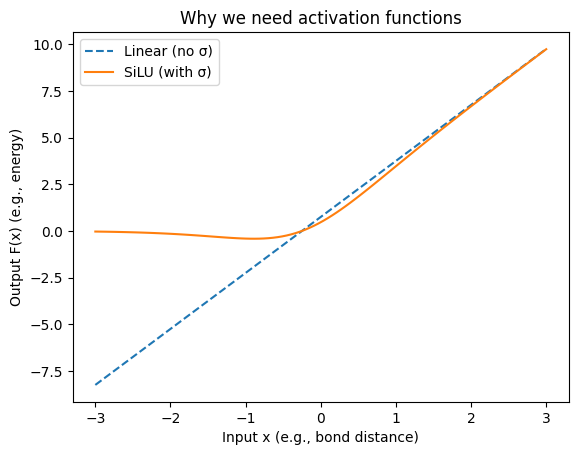

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# A single neuron
w2 = torch.tensor(2.0, requires_grad=True)
b1 = torch.tensor(0.5, requires_grad=True)
w1 = torch.tensor(1.5, requires_grad=True)
b2 = torch.tensor(0.0, requires_grad=True)

x = torch.linspace(-3, 3, 100)

# Without activation: straight line
linear = w1 * (w2 * x + b1) + b2

# With SiLU activation: curved!
silu = nn.SiLU()
nonlinear = w1 * silu(w2 * x + b1) + b2

plt.plot(x.detach(), linear.detach(), '--', label='Linear (no σ)')
plt.plot(x.detach(), nonlinear.detach(), '-', label='SiLU (with σ)')
plt.xlabel('Input x (e.g., bond distance)')
plt.ylabel('Output F(x) (e.g., energy)')
plt.legend()
plt.title('Why we need activation functions')
plt.savefig('neuron_demo.png', dpi=150)
plt.show()

## Parameter-by-Parameter Breakdown

Let's visualize what each parameter does.

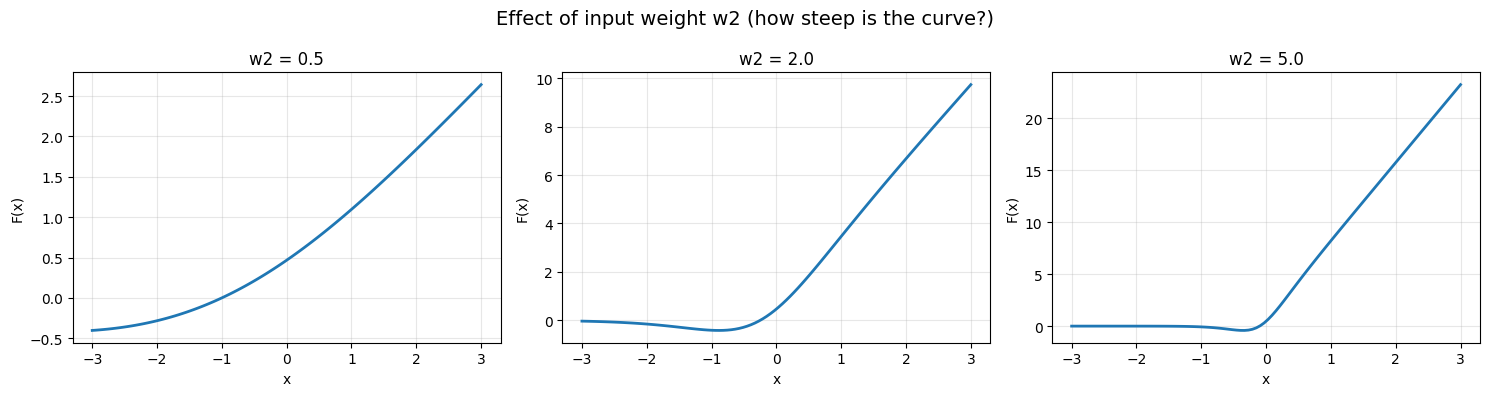

In [4]:
# ============================================================
# EFFECT OF w2 (Input Weight)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

w2_values = [0.5, 2.0, 5.0]
for ax, w2_val in zip(axes, w2_values):
    w2 = torch.tensor(w2_val)
    b1 = torch.tensor(0.5)
    w1 = torch.tensor(1.5)
    b2 = torch.tensor(0.0)
    x = torch.linspace(-3, 3, 100)
    y = w1 * silu(w2 * x + b1) + b2
    ax.plot(x, y, linewidth=2)
    ax.set_title(f'w2 = {w2_val}', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('F(x)')
    ax.grid(True, alpha=0.3)
plt.suptitle('Effect of input weight w2 (how steep is the curve?)', fontsize=14)
plt.tight_layout()
plt.savefig('parameter_w2.png', dpi=150)
plt.show()

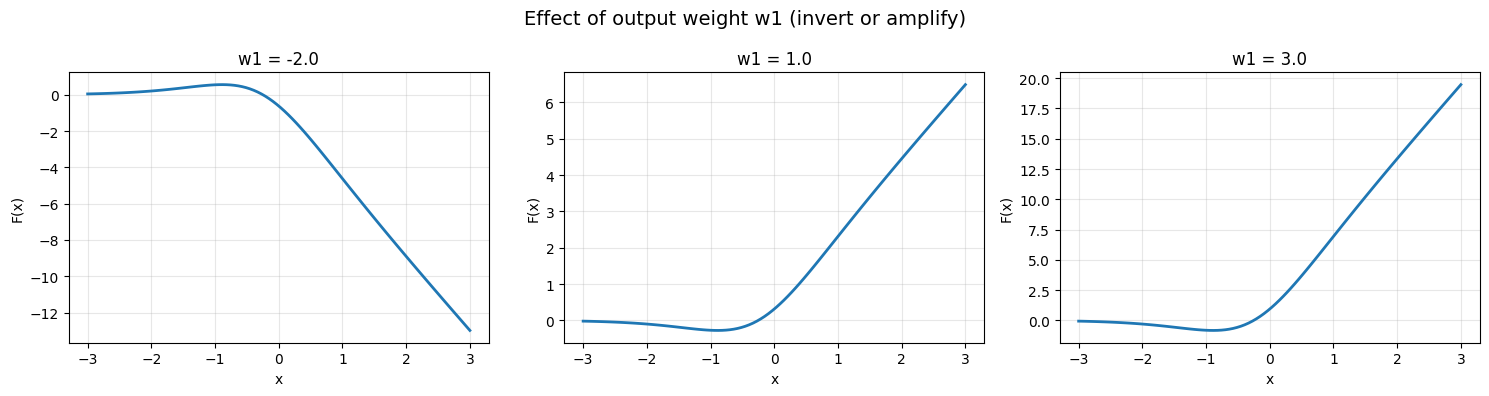

In [5]:
# ============================================================
# EFFECT OF w1 (Output Weight)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

w1_values = [-2.0, 1.0, 3.0]
for ax, w1_val in zip(axes, w1_values):
    w2 = torch.tensor(2.0)
    b1 = torch.tensor(0.5)
    w1 = torch.tensor(w1_val)
    b2 = torch.tensor(0.0)
    x = torch.linspace(-3, 3, 100)
    y = w1 * silu(w2 * x + b1) + b2
    ax.plot(x, y, linewidth=2)
    ax.set_title(f'w1 = {w1_val}', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('F(x)')
    ax.grid(True, alpha=0.3)
plt.suptitle('Effect of output weight w1 (invert or amplify)', fontsize=14)
plt.tight_layout()
plt.savefig('parameter_w1.png', dpi=150)
plt.show()

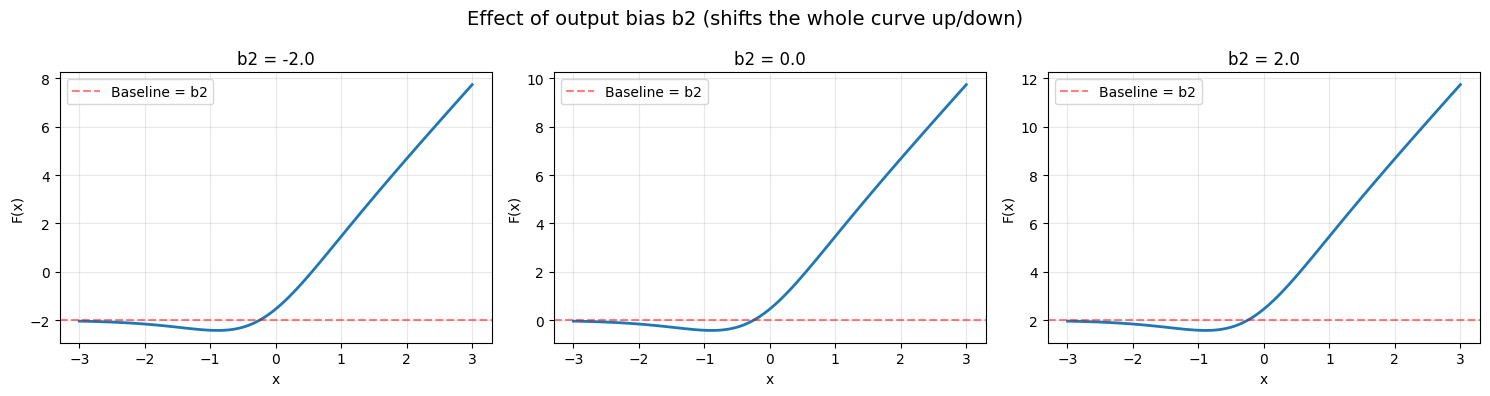

In [6]:
# ============================================================
# EFFECT OF b2 (Output Bias)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

b2_values = [-2.0, 0.0, 2.0]
for ax, b2_val in zip(axes, b2_values):
    w2 = torch.tensor(2.0)
    b1 = torch.tensor(0.5)
    w1 = torch.tensor(1.5)
    b2 = torch.tensor(b2_val)
    x = torch.linspace(-3, 3, 100)
    y = w1 * silu(w2 * x + b1) + b2
    ax.plot(x, y, linewidth=2)
    ax.axhline(y=b2_val, color='red', linestyle='--', alpha=0.5,
               label=f'Baseline = b2')
    ax.set_title(f'b2 = {b2_val}', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('F(x)')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Effect of output bias b2 (shifts the whole curve up/down)', fontsize=14)
plt.tight_layout()
plt.savefig('parameter_b2.png', dpi=150)
plt.show()

## Activation Functions: The Non-Linearity

Without σ, stacking neurons is pointless—the composition of linear functions is still linear.

The activation function is what gives neural networks their power.

Here are the main candidates:

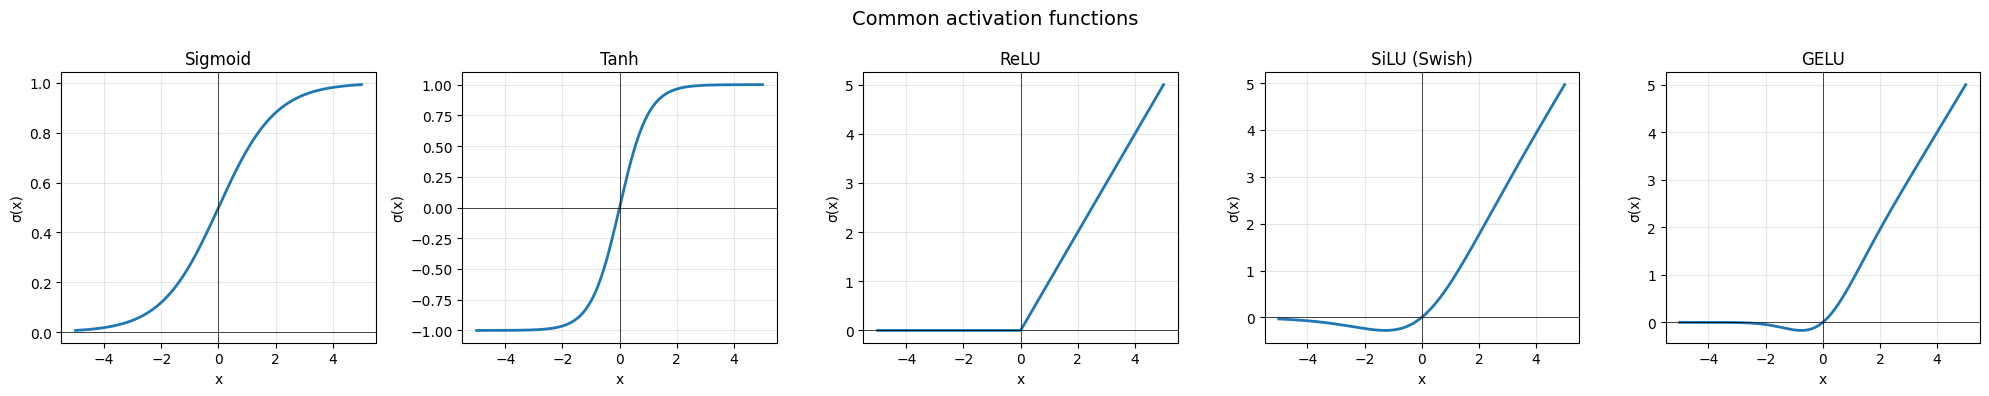

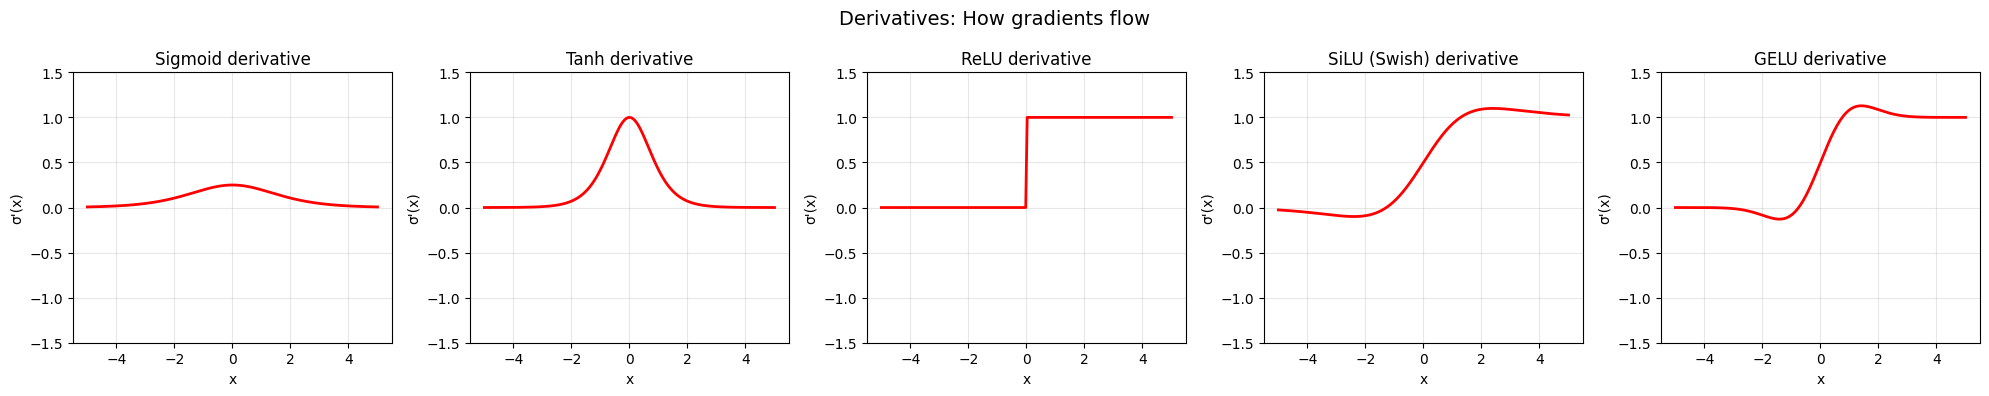

In [7]:
# ============================================================
# COMPARE ACTIVATION FUNCTIONS
# ============================================================
import torch.nn as nn

x = torch.linspace(-5, 5, 200)

activations = {
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'ReLU': nn.ReLU(),
    'SiLU (Swish)': nn.SiLU(),
    'GELU': nn.GELU(),
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, act) in zip(axes, activations.items()):
    y = act(x)
    ax.plot(x, y, linewidth=2)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('σ(x)')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
plt.suptitle('Common activation functions', fontsize=14)
plt.tight_layout()
plt.savefig('activation_functions.png', dpi=150)
plt.show()

# ============================================================
# DERIVATIVES (critical for gradient flow)
# ============================================================
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, act) in zip(axes, activations.items()):
    x_g = x.clone().requires_grad_(True)
    y = act(x_g)
    dy = torch.autograd.grad(y.sum(), x_g)[0]
    ax.plot(x.detach(), dy.detach(), linewidth=2, color='red')
    ax.set_title(f"{name} derivative", fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel("σ'(x)")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.5, 1.5)
plt.suptitle('Derivatives: How gradients flow', fontsize=14)
plt.tight_layout()
plt.savefig('activation_derivatives.png', dpi=150)
plt.show()

### Which Activation Function to Use?

| Function | Pros | Cons | Used in |
|:---|:---|:---|:---|
| **Sigmoid** | Smooth, bounded | Vanishing gradients | Old networks, binary classification |
| **Tanh** | Zero-centered | Vanishing gradients | RNNs |
| **ReLU** | Fast, no vanishing gradient | Dead neurons | CNNs, old MLFFs |
| **SiLU** | Smooth, non-monotonic | Slightly slower | **MACE, NequIP, modern MLFFs** |
| **GELU** | Smooth, state-of-art | Slower | Transformers, LLMs |

**For MLFFs: SiLU is the standard.** It's smooth, differentiable, and works well with force computations.

## One Neuron Can't Do Much — But Many Can

A single neuron can only learn a single "bend" in the curve.

To learn a real potential energy surface (with wells, barriers, and repulsive walls), we need **many neurons**.

Let's see what happens when we sum up multiple neurons.

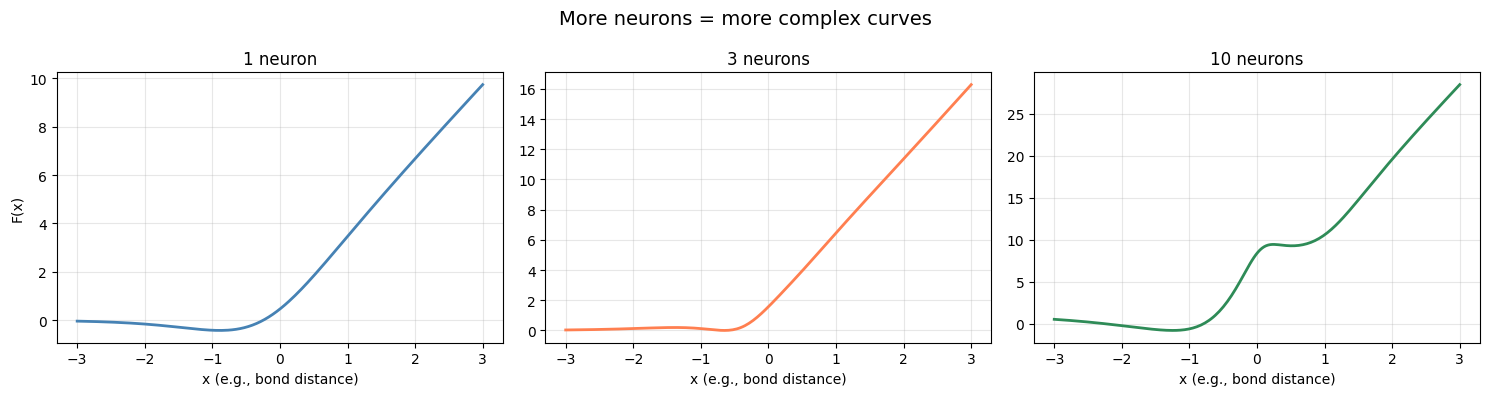

With 10 neurons, we start to see multiple wells and barriers.
With 1000 neurons, we can fit almost any smooth PES.


In [8]:
# ============================================================
# SUM OF MULTIPLE NEURONS
# ============================================================

def single_neuron(x, w1, b1, w2, b2):
    silu = nn.SiLU()
    return w1 * silu(w2 * x + b1) + b2

x = torch.linspace(-3, 3, 200)

# ============================================================
# 1 NEURON
# ============================================================
y1 = single_neuron(x, w1=1.5, b1=0.5, w2=2.0, b2=0.0)

# ============================================================
# 3 NEURONS SUMMED
# ============================================================
y3 = (single_neuron(x, w1=1.0, b1=-1.0, w2=3.0, b2=0.0) +
      single_neuron(x, w1=-2.0, b1=0.0, w2=2.0, b2=0.0) +
      single_neuron(x, w1=1.5, b1=1.5, w2=4.0, b2=0.0))

# ============================================================
# 10 NEURONS SUMMED (random params)
# ============================================================
torch.manual_seed(42)
y10 = torch.zeros_like(x)
for _ in range(10):
    w1 = torch.randn(1) * 2
    b1 = torch.randn(1) * 2
    w2 = torch.randn(1).abs() * 3 + 0.5
    b2 = torch.randn(1) * 0.5
    y10 += single_neuron(x, w1, b1, w2, b2)

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x, y1, linewidth=2, color='steelblue')
axes[0].set_title('1 neuron', fontsize=12)
axes[0].set_ylabel('F(x)')

axes[1].plot(x, y3, linewidth=2, color='coral')
axes[1].set_title('3 neurons', fontsize=12)

axes[2].plot(x, y10, linewidth=2, color='seagreen')
axes[2].set_title('10 neurons', fontsize=12)

for ax in axes:
    ax.set_xlabel('x (e.g., bond distance)')
    ax.grid(True, alpha=0.3)

plt.suptitle('More neurons = more complex curves', fontsize=14)
plt.tight_layout()
plt.savefig('neuron_sum.png', dpi=150)
plt.show()

print("With 10 neurons, we start to see multiple wells and barriers.")
print("With 1000 neurons, we can fit almost any smooth PES.")

### The Universal Approximation Theorem

> *"A neural network with a single hidden layer and enough neurons can approximate any continuous function on a compact set to arbitrary accuracy."*

**In plain English:** With enough neurons, you can fit any smooth potential energy surface.

**But there's a catch:** More neurons = more parameters = more data needed to train.

This is why we don't just use 1 million neurons for everything—we balance model capacity with data availability.

## From Neuron to Force Field

Here's how this connects to what you'll do in LAMMPS:

1. **Input:** Atomic positions → converted to descriptors (distances, angles, SOAP)
2. **Hidden layers:** Thousands of neurons like the ones we just built
3. **Output:** Total energy E
4. **Forces:** Computed via autograd: F = -∇E

A neural network potential (NNP) is just this—a big function that takes atomic coordinates and returns energy.

**The training process:**
- Start with random weights
- Predict energy for a known structure
- Compute loss (predicted E vs. DFT E)
- Backpropagate and update weights
- Repeat until accurate

**This is exactly what MACE, NequIP, and SchNet do—just with more sophisticated architectures.**

## Summary: What We Learned

| Concept | Key Takeaway |
|:---|:---|
| **Tensors** | Arrays that track gradients (autograd) |
| **Neuron equation** | \( F(x) = w_1 \sigma(w_2 x + b_1) + b_2 \) |
| **Activation** | Non-linearity is what makes NNs powerful |
| **Parameters** | w2 = steepness, b1 = turn location, w1 = amplitude, b2 = offset |
| **Multiple neurons** | More neurons = more complex curves |
| **Universal approximation** | Enough neurons can fit any smooth PES |